# Fashion Recommendation Testing Notebook

This notebook is intended for **testing** the fashion recommendation pipeline.

To run the default tests, simply **run all cells**.

---

## Testing with Your Own Image

If you want to test with a custom image:

1.  **Upload** your desired image to this notebook's environment.
2.  Update the `image_path` argument in both the `recommend_similar_images` and `recommend_similar_clip_images` function calls to the path of your uploaded file.

---

## Text-Based Testing

For the final cell in the notebook, which handles text-to-image recommendations:

1.  Run the cell.
2.  After it executes, **enter the text description** of the fashion item you're looking for and click **Enter**.

In [ ]:
import kagglehub
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.neighbors import NearestNeighbors
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel
import torch

In [ ]:
# Download dataset
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset")

print("Path to dataset:", path)
print("\nFiles and folders inside:")
print(os.listdir(path))

Using Colab cache for faster access to the 'fashion-product-images-dataset' dataset.
Path to dataset: /kaggle/input/fashion-product-images-dataset

Files and folders inside:
['fashion-dataset']


In [ ]:
sub_path = os.path.join(path, "fashion-dataset")
print("Path inside dataset:", sub_path)
print("\nFiles and folders inside:")
print(os.listdir(sub_path))

Path inside dataset: /kaggle/input/fashion-product-images-dataset/fashion-dataset

Files and folders inside:
['images.csv', 'images', 'styles.csv', 'styles', 'fashion-dataset']


In [ ]:
# Download features
features_path = kagglehub.dataset_download("adityakammati/fashion-recomendation-dataset")

print("Path to dataset files:", features_path)

100%|██████████| 135M/135M [00:00<00:00, 165MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/adityakammati/fashion-recomendation-dataset/versions/1


In [ ]:
for root, dirs, files in os.walk(features_path):
    level = root.replace(features_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

1/
    clip_image_features.npy
    fashion_features.npy
    fashion_metadata.csv
    hoodie.png


In [ ]:
# Dynamically get file paths
fashion_features_path = os.path.join(features_path, "fashion_features.npy")
clip_features_path = os.path.join(features_path, "clip_image_features.npy")
metadata_path = os.path.join(features_path, "fashion_metadata.csv")
image_path = os.path.join(features_path, "hoodie.png")

print("Image path:", image_path)

# Load features
features = np.load(fashion_features_path)
print("VGG16 features shape:", features.shape)

# Load CLIP features
clip_features = np.load(clip_features_path)
print("CLIP features shape:", clip_features.shape)

# Load metadata
metadata = pd.read_csv(metadata_path)
print("Metadata shape:", metadata.shape)
print(metadata.head())

Image path: /root/.cache/kagglehub/datasets/adityakammati/fashion-recomendation-dataset/versions/1/hoodie.png
VGG16 features shape: (44419, 512)
CLIP features shape: (44419, 512)
Metadata shape: (44419, 11)
      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  \
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt   
1  2012.0  Casual             Peter England Men Party Blue Jeans   
2  2016.0  Casual                       Titan Women Silver Watch   
3  2011.0  Casual  Manchester United Men Solid Black

In [ ]:
# Download latest version of the model
model_path = kagglehub.model_download("adityakammati/vgg16-fashion-recommendation/keras/default")
print("Path to model files:", model_path)

# Find the .keras or .h5 file dynamically
model_file = None
for f in os.listdir(model_path):
    if f.endswith(".keras") or f.endswith(".h5"):
        model_file = os.path.join(model_path, f)
        break

if model_file is None:
    raise FileNotFoundError("No .keras or .h5 model file found in the downloaded folder.")

# Load the model
vgg_model = tf.keras.models.load_model(model_file)
print("Model loaded successfully!")

# Optional: print summary
vgg_model.summary()


  0%|          | 0.00/56.2M [00:00<?, ?B/s]
  2%|▏         | 1.00M/56.2M [00:00<00:21, 2.68MB/s]
  5%|▌         | 3.00M/56.2M [00:00<00:07, 7.48MB/s]
 16%|█▌        | 9.00M/56.2M [00:00<00:02, 21.7MB/s]
 23%|██▎       | 13.0M/56.2M [00:00<00:02, 22.1MB/s]
 28%|██▊       | 16.0M/56.2M [00:00<00:01, 24.4MB/s]
 39%|███▉      | 22.0M/56.2M [00:01<00:01, 32.7MB/s]
 48%|████▊     | 27.0M/56.2M [00:01<00:00, 31.6MB/s]
 57%|█████▋    | 32.0M/56.2M [00:01<00:00, 36.0MB/s]
 66%|██████▌   | 37.0M/56.2M [00:01<00:00, 36.2MB/s]
 78%|███████▊  | 44.0M/56.2M [00:01<00:00, 42.7MB/s]
100%|██████████| 56.2M/56.2M [00:01<00:00, 33.5MB/s]


Path to model files: /root/.cache/kagglehub/models/adityakammati/vgg16-fashion-recommendation/keras/default/1
Model loaded successfully!


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

/kaggle/input/fashion-product-images-dataset/fashion-dataset


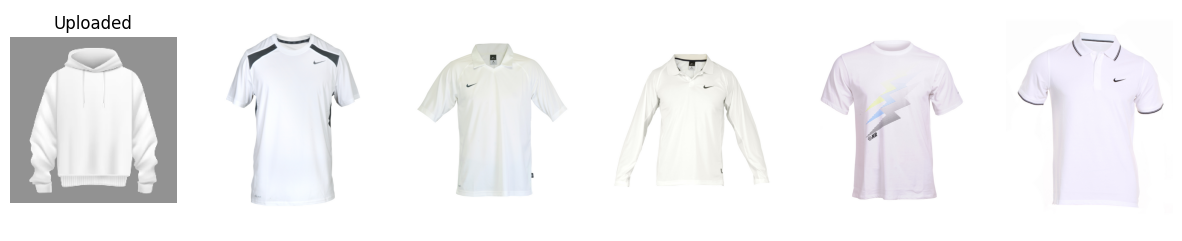

In [ ]:
# Build KNN model
knn = NearestNeighbors(n_neighbors=5, metric='cosine')
knn.fit(features)

def recommend_similar_images(img_path, n_recommendations=5):
    # Load and preprocess uploaded image
    uploaded_img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(uploaded_img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Extract feature vector using VGG16
    feature_vector = vgg_model.predict(img_array, verbose=0)

    # Find nearest neighbors
    distances, indices = knn.kneighbors(feature_vector, n_neighbors=n_recommendations)

    # Display uploaded + recommended images
    plt.figure(figsize=(15,5))

    # Show uploaded image first
    plt.subplot(1, n_recommendations + 1, 1)
    plt.imshow(uploaded_img)
    plt.title("Uploaded")
    plt.axis("off")

    print(sub_path)

    # Show recommended images
    for i, idx in enumerate(indices[0]):
        rec_img_path = metadata.iloc[idx]["image_path"]
        rec_img_path = rec_img_path.replace("/kaggle/input/fashion-product-images-dataset/fashion-dataset", sub_path)
        # print(rec_img_path)
        rec_img = Image.open(rec_img_path)
        plt.subplot(1, n_recommendations + 1, i + 2)
        plt.imshow(rec_img)
        plt.axis("off")

    plt.show()

# Example usage: replace with your uploaded image
recommend_similar_images(image_path, n_recommendations=5)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

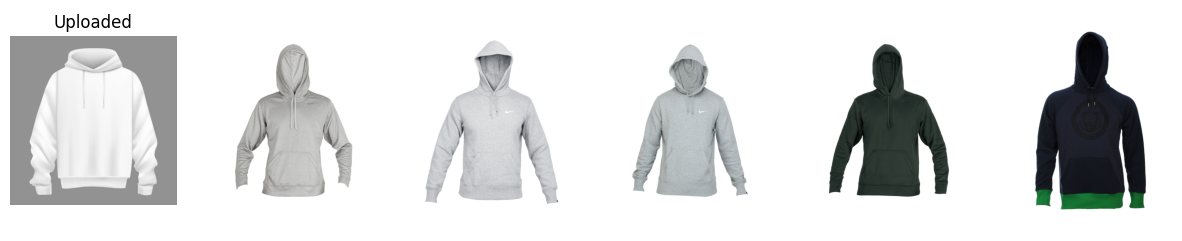

In [ ]:

# Build KNN model on CLIP features
knn_clip = NearestNeighbors(n_neighbors=5, metric='cosine')
knn_clip.fit(clip_features)

# Load CLIP model and processor
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def get_clip_feature_from_image(img_path_or_pil):
    """Extract CLIP feature vector from uploaded image"""
    if isinstance(img_path_or_pil, str):
        img = Image.open(img_path_or_pil).convert("RGB")
    else:
        img = img_path_or_pil.convert("RGB")

    inputs = clip_processor(images=img, return_tensors="pt")
    with torch.no_grad():
        features = clip_model.get_image_features(**inputs)
    features = features.cpu().numpy().reshape(-1)
    return features

def recommend_similar_clip_images(img_path, n_recommendations=5):
    """Display similar images using CLIP features"""
    # Extract feature vector
    feature_vector = get_clip_feature_from_image(img_path).reshape(1, -1)

    # Find nearest neighbors
    distances, indices = knn_clip.kneighbors(feature_vector, n_neighbors=n_recommendations)

    # Display recommended images
    plt.figure(figsize=(15,5))

    # Show uploaded image first
    uploaded_img = Image.open(img_path)
    plt.subplot(1, n_recommendations+1, 1)
    plt.imshow(uploaded_img)
    plt.title("Uploaded")
    plt.axis("off")

    for i, idx in enumerate(indices[0]):
        img_path_rec = metadata.iloc[idx]["image_path"]
        img_path_rec = img_path_rec.replace("/kaggle/input/fashion-product-images-dataset/fashion-dataset", sub_path)
        rec_img = Image.open(img_path_rec)
        plt.subplot(1, n_recommendations+1, i+2)
        plt.imshow(rec_img)
        plt.axis("off")

    plt.show()

# Example usage: replace with user-uploaded image path
recommend_similar_clip_images(image_path, n_recommendations=5)

Enter a text description to search images: a white hoodie 


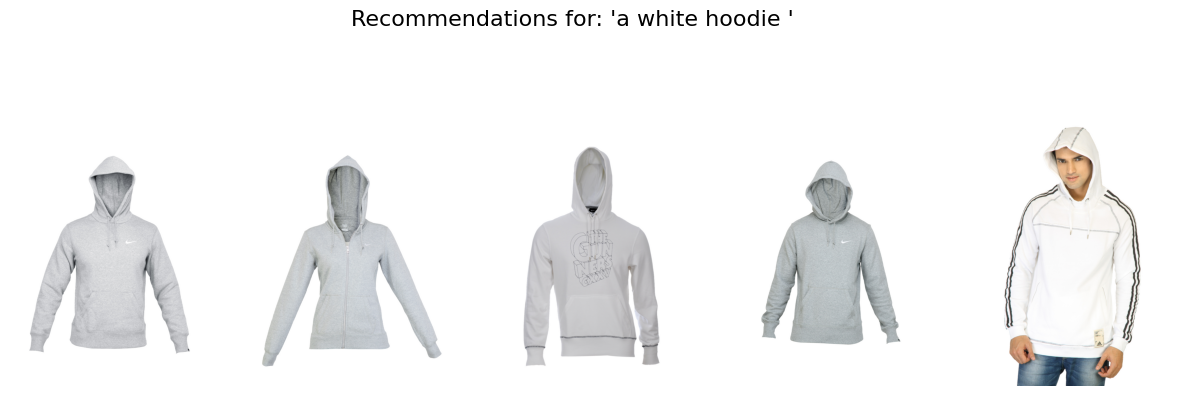

In [ ]:
def recommend_images_from_text(query, n_recommendations=5):
    """Recommend images based on user text input"""
    # Convert text to CLIP feature vector
    inputs = clip_processor(text=[query], return_tensors="pt", padding=True)
    with torch.no_grad():
        text_features = clip_model.get_text_features(**inputs)
    text_features = text_features.cpu().numpy().reshape(1, -1)

    # Find nearest neighbors
    distances, indices = knn_clip.kneighbors(text_features, n_neighbors=n_recommendations)

    # Display recommended images
    plt.figure(figsize=(15,5))
    plt.suptitle(f"Recommendations for: '{query}'", fontsize=16)

    for i, idx in enumerate(indices[0]):
        img_path_rec = metadata.iloc[idx]["image_path"]
        img_path_rec = img_path_rec.replace("/kaggle/input/fashion-product-images-dataset/fashion-dataset", sub_path)
        rec_img = Image.open(img_path_rec)
        plt.subplot(1, n_recommendations, i+1)
        plt.imshow(rec_img)
        plt.axis("off")

    plt.show()

# Example usage: take input from user
user_query = input("Enter a text description to search images: ")
recommend_images_from_text(user_query, n_recommendations=5)